# 06 — EBM Calibration Curve

This notebook evaluates whether the `best_ebm_model` is **well-calibrated**.

A model is well-calibrated if, for example, patients assigned ~80% probability of a poor outcome actually have a poor outcome ~80% of the time.

We use the held-out **test set** (never seen during training or tuning) to get an honest estimate.

## 1. Imports

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve, CalibrationDisplay

## 2. Load model and test data

In [4]:
# Load the saved EBM model
ebm = joblib.load('../models/best_ebm_model.joblib')
print('Model loaded:', type(ebm).__name__)

# Load test set (held-out data — never used during training or hyperparameter tuning)
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f'Test set: {X_test.shape[0]:,} samples | Positive rate: {y_test.mean():.3f}')

Model loaded: ExplainableBoostingClassifier
Test set: 26,477 samples | Positive rate: 0.180


## 3. Get predicted probabilities

In [5]:
# Predicted probability of the positive class (poor outcome)
y_prob = ebm.predict_proba(X_test)[:, 1]

print(f'Probability range: [{y_prob.min():.3f}, {y_prob.max():.3f}]')
print(f'Mean predicted probability: {y_prob.mean():.3f}')
print(f'Actual positive rate:        {y_test.mean():.3f}')

Probability range: [0.037, 1.000]
Mean predicted probability: 0.182
Actual positive rate:        0.180


## 4. Calibration curve

`calibration_curve` bins the predicted probabilities and computes the fraction of positives in each bin.

- **Perfect calibration**: all points fall on the diagonal.
- **Above diagonal**: model is underconfident (true rate is higher than predicted).
- **Below diagonal**: model is overconfident (true rate is lower than predicted).

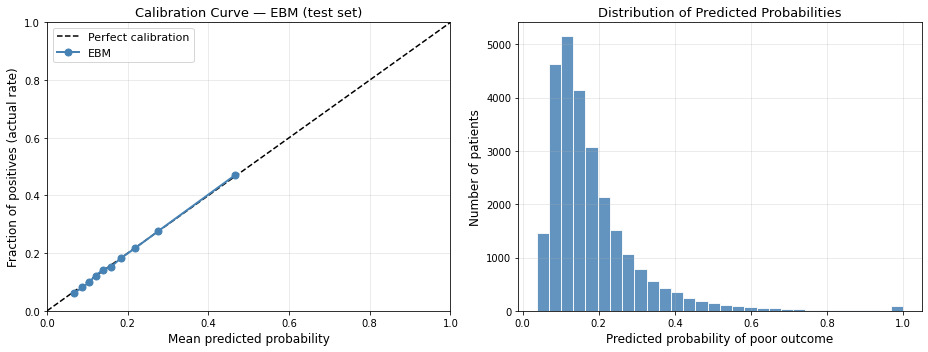

In [6]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: calibration curve ---
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1.5)
ax.plot(prob_pred, prob_true, 'o-', color='steelblue', linewidth=2,
        markersize=7, label='EBM')
ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives (actual rate)', fontsize=12)
ax.set_title('Calibration Curve — EBM (test set)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# --- Right: histogram of predicted probabilities ---
ax2 = axes[1]
ax2.hist(y_prob, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax2.set_xlabel('Predicted probability of poor outcome', fontsize=12)
ax2.set_ylabel('Number of patients', fontsize=12)
ax2.set_title('Distribution of Predicted Probabilities', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Calibration in numbers

Let's print the bin-level table so we can see exactly how far off each bucket is.

In [7]:
cal_df = pd.DataFrame({
    'Predicted probability (bin centre)': prob_pred.round(3),
    'Actual positive rate':               prob_true.round(3),
    'Difference (actual - predicted)':    (prob_true - prob_pred).round(3)
})
print(cal_df.to_string(index=False))

mean_abs_error = np.abs(prob_true - prob_pred).mean()
print(f'\nMean absolute calibration error: {mean_abs_error:.4f}')

 Predicted probability (bin centre)  Actual positive rate  Difference (actual - predicted)
                              0.066                 0.061                           -0.005
                              0.088                 0.081                           -0.007
                              0.104                 0.099                           -0.005
                              0.120                 0.122                            0.002
                              0.138                 0.141                            0.004
                              0.158                 0.152                           -0.006
                              0.183                 0.183                           -0.001
                              0.218                 0.217                           -0.001
                              0.275                 0.276                            0.001
                              0.467                 0.471                            0.004

## 6. What do the results tell you?

| Observation | Interpretation |
|---|---|
| Points close to the diagonal | The 87% the EBM outputs is trustworthy as an actual probability |
| Points above the diagonal | The model is underconfident — e.g. it says 87% but reality is ~92% |
| Points below the diagonal | The model is overconfident — e.g. it says 87% but reality is ~75% |
| Most predictions bunched near 0 or 1 (histogram) | Model is very decisive; overconfidence is a common risk here |

If the calibration is poor, you can apply a post-hoc correction such as **Platt scaling** (logistic regression on the predicted probabilities) or **isotonic regression**, both available in `sklearn.calibration.CalibratedClassifierCV`.